<a href="https://colab.research.google.com/github/sairamsrujan/celebal-excellence-internship/blob/main/Week3_RSaiRamSrujanKumar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Intelligence System
### Classification, Ensemble Learning & Clustering

**Objective:** Build a customer intelligence system using clustering (K-Means, K-Medoids, DBSCAN, Hierarchical) and classification/ensemble models (Logistic Regression, Naive Bayes, KNN, SVM, Decision Tree, Random Forest, AdaBoost, Gradient Boosting, XGBoost, LightGBM, Stacking) on country-level socio-economic data.

## Section 1 - Installing Libraries

In [ ]:
!pip install "numpy<2" pandas matplotlib seaborn scikit-learn xgboost lightgbm scipy scikit-learn-extra -q

## Section 2 - Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn_extra.cluster import KMedoids
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# classification models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# for hierarchical clustering dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## Section 3 - Loading the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Country-data.csv to Country-data (1).csv


In [ ]:
df = pd.read_csv('Country-data.csv')
print('Shape:', df.shape)
df.head()

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


## Section 4 - Data Cleaning

- Strip whitespace from column names
- Drop duplicates
- Force numeric types
- Impute missing values with median

In [ ]:
# strip whitespace from column titles
df.columns = df.columns.str.strip()
print('Columns:', df.columns.tolist())

Columns: ['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [ ]:
# drop duplicate records
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates()
print('Duplicates after:', df.duplicated().sum())
print('Shape:', df.shape)

Duplicates before: 0
Duplicates after: 0
Shape: (167, 10)


In [ ]:
# force numeric types on feature columns
feature_cols = df.columns.drop('country')
for col in feature_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
country,object
child_mort,float64
exports,float64
health,float64
imports,float64
income,int64
inflation,float64
life_expec,float64
total_fer,float64
gdpp,int64


In [ ]:
# check missing values and impute with median
print('Missing values:')
print(df.isnull().sum())

for col in feature_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f'Imputed {col} with median = {median_val:.2f}')

print('\nAfter imputation:')
print(df.isnull().sum())

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

After imputation:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## Section 5 - Exploratory Data Analysis

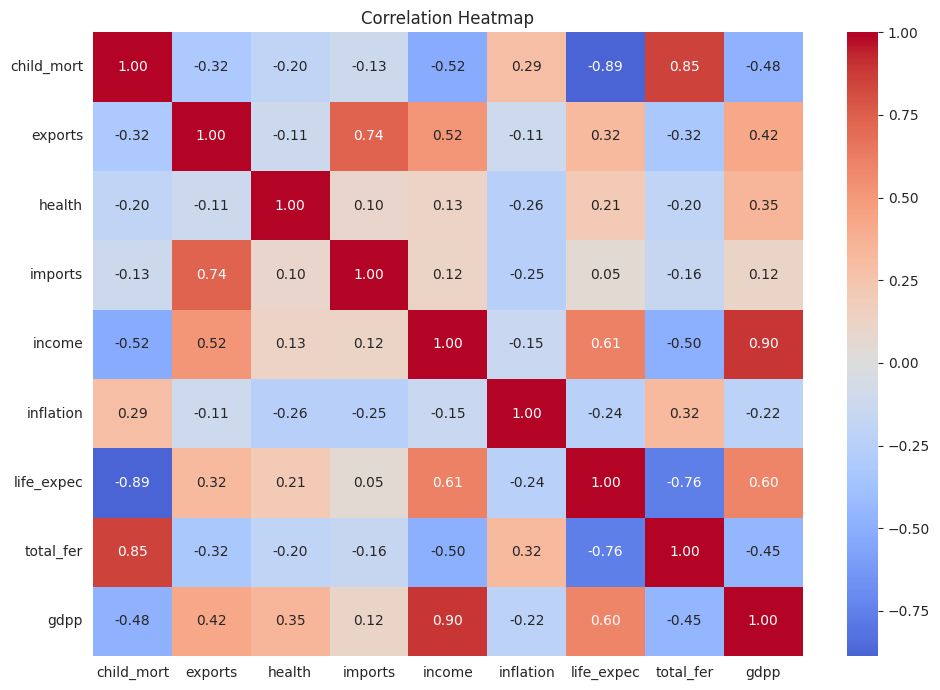

In [ ]:
# correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df[feature_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

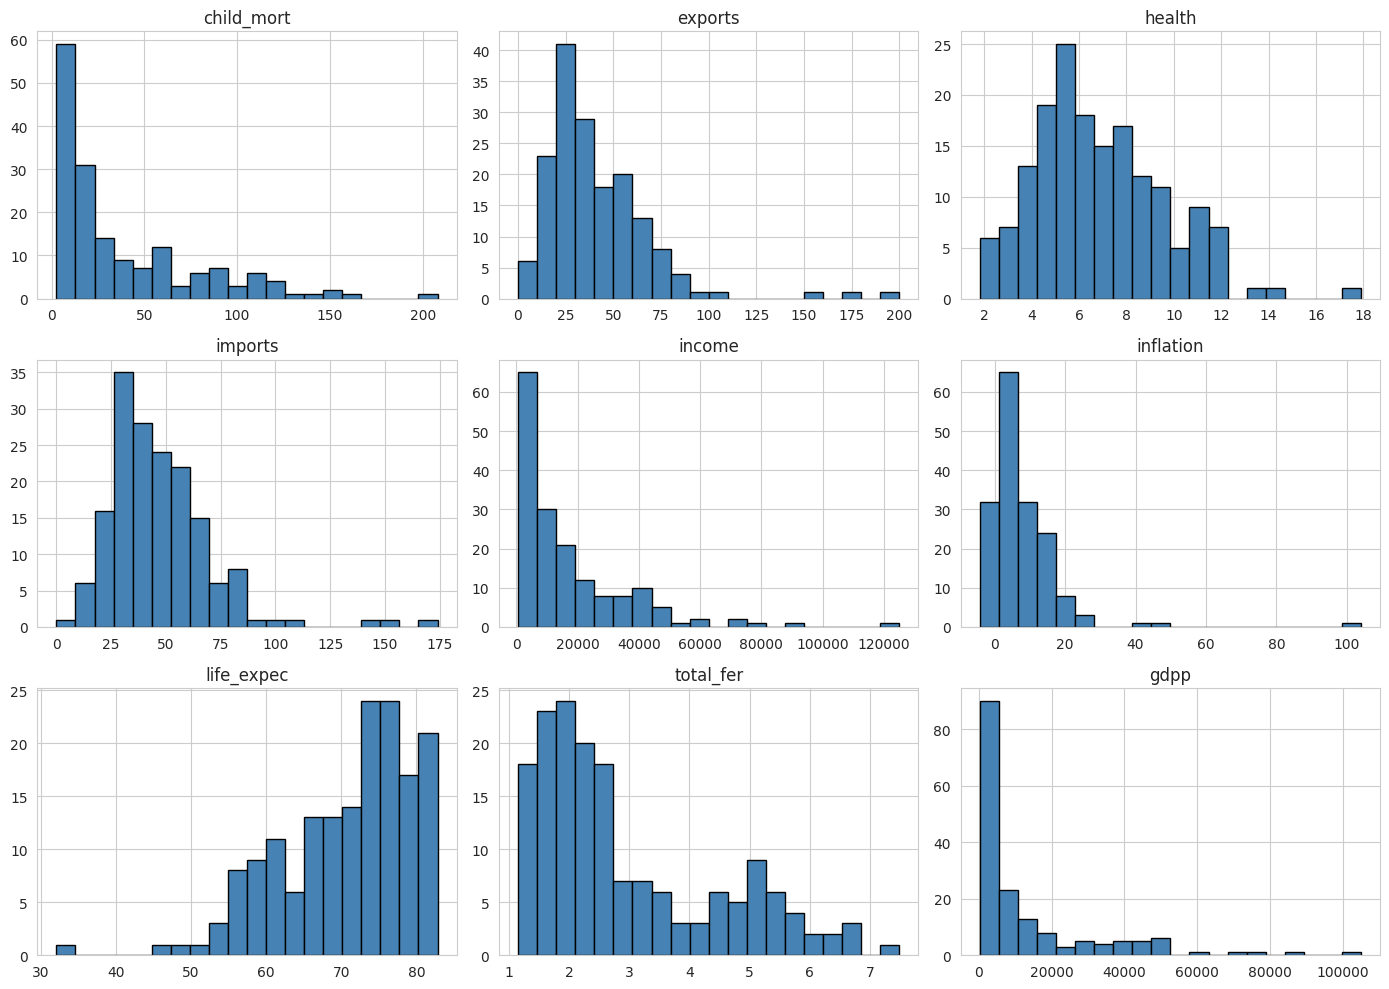

In [ ]:
# feature distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
for i, col in enumerate(feature_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df[col], bins=20, color='steelblue', edgecolor='black')
    ax.set_title(col)
plt.tight_layout()
plt.show()

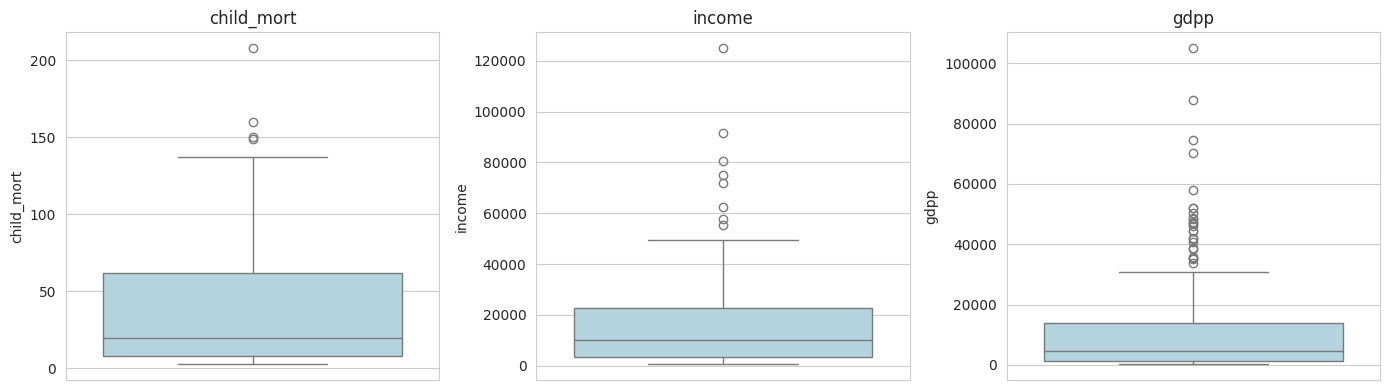

In [ ]:
# boxplots to check for outliers in key features
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(['child_mort', 'income', 'gdpp']):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

## Section 6 - Feature Isolation and Scaling

Strip the country name identifier to isolate continuous features. Then scale using StandardScaler.

In [ ]:
# isolate numeric features (drop country column)
X = df.drop(columns=['country'])
country_names = df['country'].values

print('Features:', X.columns.tolist())
print('Shape:', X.shape)

# scale using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\nMean after scaling:', X_scaled.mean(axis=0).round(4))
print('Std after scaling:', X_scaled.std(axis=0).round(4))

Features: ['child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']
Shape: (167, 9)

Mean after scaling: [-0.  0.  0.  0. -0. -0.  0.  0.  0.]
Std after scaling: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Section 7 - Elbow Method

Testing cluster ranges k in [2, 10] and plotting inertia values.

In [ ]:
k_range = range(2, 11)
inertia_values = []
sil_scores_list = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X_scaled)
    inertia_values.append(km.inertia_)
    score = silhouette_score(X_scaled, km.labels_)
    sil_scores_list.append(score)
    print(f'k={k}  Inertia={km.inertia_:.2f}  Silhouette={score:.4f}')

print(f'\nBest k by silhouette: {list(k_range)[np.argmax(sil_scores_list)]}')

k=2  Inertia=1050.21  Silhouette=0.2874
k=3  Inertia=831.42  Silhouette=0.2833
k=4  Inertia=700.58  Silhouette=0.3004
k=5  Inertia=619.94  Silhouette=0.3044
k=6  Inertia=552.18  Silhouette=0.2330
k=7  Inertia=496.54  Silhouette=0.2502
k=8  Inertia=450.75  Silhouette=0.2469
k=9  Inertia=429.53  Silhouette=0.2237
k=10  Inertia=399.34  Silhouette=0.2092

Best k by silhouette: 5


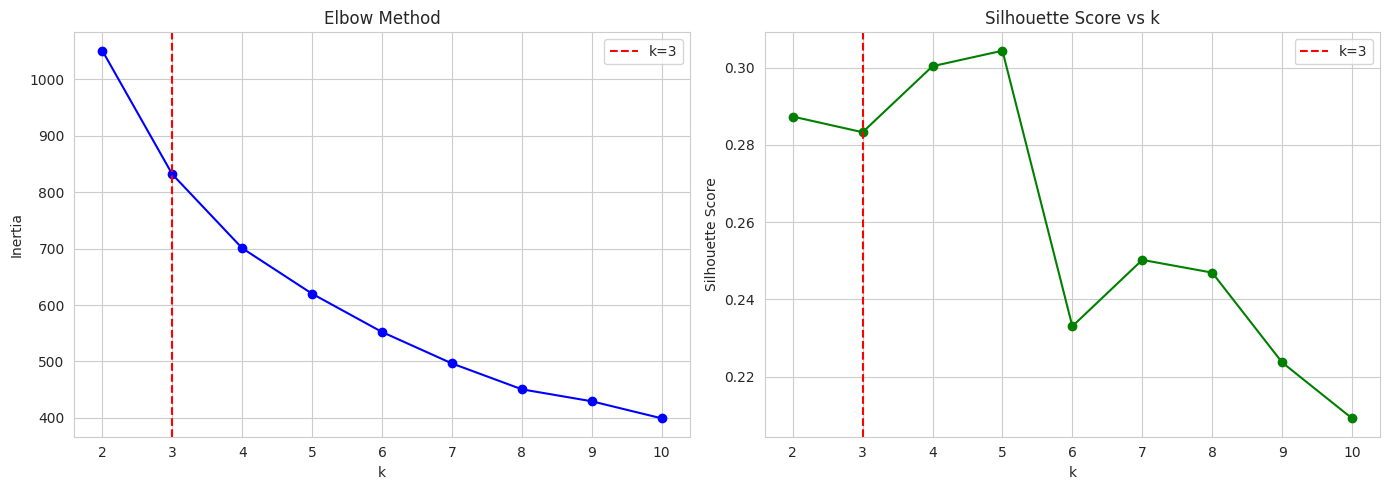

In [ ]:
# elbow plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(list(k_range), inertia_values, 'o-', color='blue')
ax1.axvline(x=3, color='red', linestyle='--', label='k=3')
ax1.set_xlabel('k')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.legend()

ax2.plot(list(k_range), sil_scores_list, 'o-', color='green')
ax2.axvline(x=3, color='red', linestyle='--', label='k=3')
ax2.set_xlabel('k')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score vs k')
ax2.legend()

plt.tight_layout()
plt.show()

## Section 8 - K-Means Clustering (k=3)

In [ ]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = kmeans_labels

print('Cluster counts:')
print(df['KMeans_Cluster'].value_counts().sort_index())

Cluster counts:
KMeans_Cluster
0    84
1    47
2    36
Name: count, dtype: int64


## Section 9 - Silhouette Score

In [ ]:
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f'Silhouette Score (k={best_k}): {sil_score:.4f}')
print(f'Inertia: {kmeans.inertia_:.2f}')

Silhouette Score (k=3): 0.2833
Inertia: 831.42


## Section 10 - Cluster Profiling

In [ ]:
# mean values per cluster
cluster_cols = ['KMeans_Cluster', 'DBSCAN_Cluster', 'Hierarchical_Cluster', 'KMedoids_Cluster']
orig_features = [c for c in df.columns if c not in ['country'] + cluster_cols]
profile = df.groupby('KMeans_Cluster')[orig_features].mean().round(2)
print(profile.T)

KMeans_Cluster         0        1         2
child_mort         21.93    92.96      5.00
exports            40.24    29.15     58.74
health              6.20     6.39      8.81
imports            47.47    42.32     51.49
income          12305.60  3942.40  45672.22
inflation           7.60    12.02      2.67
life_expec         72.81    59.19     80.13
total_fer           2.31     5.01      1.75
gdpp             6486.45  1922.38  42494.44


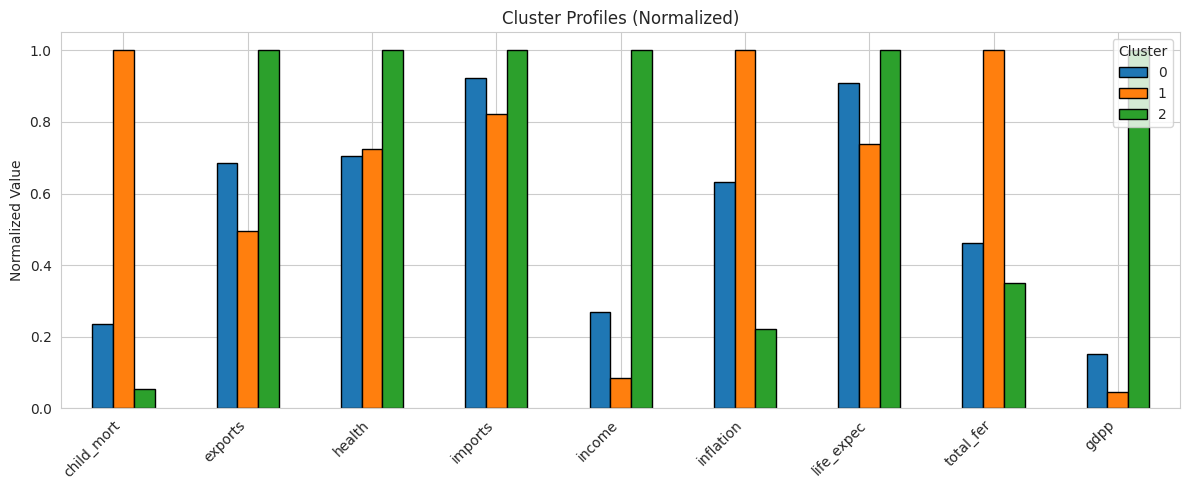

In [ ]:
# normalized bar chart for cluster comparison
profile_norm = profile.copy()
for col in profile_norm.columns:
    mx = profile_norm[col].max()
    if mx != 0:
        profile_norm[col] = profile_norm[col] / mx

profile_norm.T.plot(kind='bar', figsize=(12, 5), edgecolor='black')
plt.title('Cluster Profiles (Normalized)')
plt.ylabel('Normalized Value')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

In [ ]:
# sample countries from each cluster
for cid in sorted(df['KMeans_Cluster'].unique()):
    countries = df[df['KMeans_Cluster'] == cid]['country'].values
    sample = ', '.join(countries[:8])
    extra = f' ... +{len(countries)-8} more' if len(countries) > 8 else ''
    print(f'Cluster {cid} ({len(countries)} countries): {sample}{extra}')

Cluster 0 (84 countries): Albania, Algeria, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bangladesh ... +76 more
Cluster 1 (47 countries): Afghanistan, Angola, Benin, Botswana, Burkina Faso, Burundi, Cameroon, Central African Republic ... +39 more
Cluster 2 (36 countries): Australia, Austria, Bahrain, Belgium, Brunei, Canada, Cyprus, Czech Republic ... +28 more


## Section 11 - DBSCAN Clustering

Using eps=1.5 and min_samples=5 as parameters.

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

df['DBSCAN_Cluster'] = dbscan_labels

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f'DBSCAN found {n_clusters_db} clusters and {n_noise} noise points')
print(df['DBSCAN_Cluster'].value_counts().sort_index())

# silhouette for DBSCAN (excluding noise)
dbscan_sil = None
if n_clusters_db >= 2:
    mask = dbscan_labels != -1
    dbscan_sil = silhouette_score(X_scaled[mask], dbscan_labels[mask])
    print(f'DBSCAN Silhouette (excl noise): {dbscan_sil:.4f}')

DBSCAN found 1 clusters and 30 noise points
DBSCAN_Cluster
-1     30
 0    137
Name: count, dtype: int64


## Section 12 - K-Medoids Clustering

K-Medoids is similar to K-Means but uses actual data points as cluster centers (medoids) instead of mean values. This makes it more robust to outliers.

In [ ]:
kmedoids = KMedoids(n_clusters=3, random_state=0)
kmedoids_labels = kmedoids.fit_predict(X_scaled)

df['KMedoids_Cluster'] = kmedoids_labels

kmed_sil = silhouette_score(X_scaled, kmedoids_labels)
print(f'K-Medoids Silhouette Score: {kmed_sil:.4f}')
print('Cluster counts:')
print(df['KMedoids_Cluster'].value_counts().sort_index())

K-Medoids Silhouette Score: 0.1562
Cluster counts:
KMedoids_Cluster
0    75
1    47
2    45
Name: count, dtype: int64


In [ ]:
# medoid countries - the actual representative country for each cluster
medoid_indices = kmedoids.medoid_indices_
print('Medoid countries (cluster representatives):')
for i, idx in enumerate(medoid_indices):
    print(f'  Cluster {i}: {country_names[idx]}')

Medoid countries (cluster representatives):
  Cluster 0: Antigua and Barbuda
  Cluster 1: Tanzania
  Cluster 2: Dominican Republic


## Section 13 - Hierarchical Clustering

Agglomerative clustering with Ward linkage and dendrogram visualization.

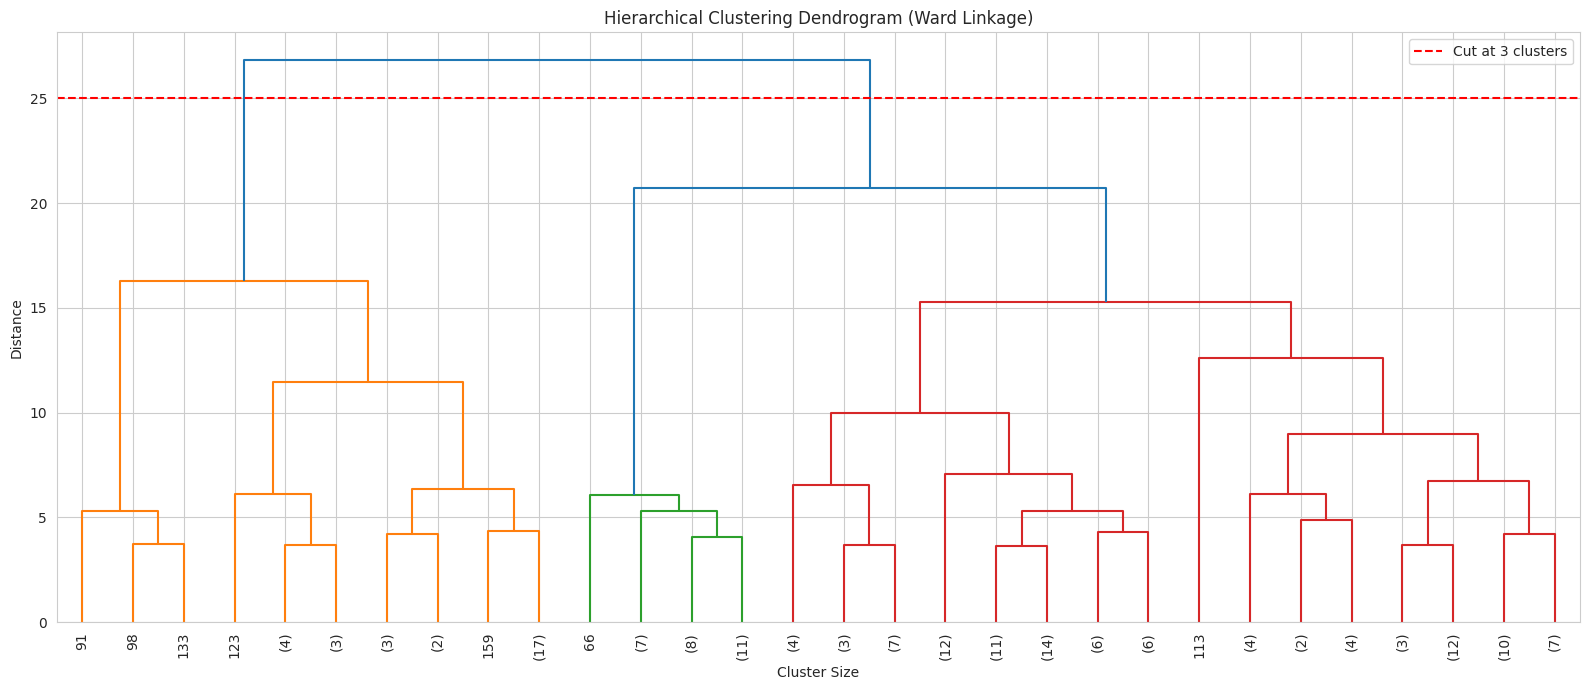

In [ ]:
# dendrogram to visualize the hierarchy
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(16, 7))
dendrogram(linked, truncate_mode='lastp', p=30, leaf_rotation=90, leaf_font_size=10)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.axhline(y=25, color='red', linestyle='--', label='Cut at 3 clusters')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# agglomerative clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = agg_labels

agg_sil = silhouette_score(X_scaled, agg_labels)
print(f'Hierarchical Clustering Silhouette Score: {agg_sil:.4f}')
print('Cluster counts:')
print(df['Hierarchical_Cluster'].value_counts().sort_index())

Hierarchical Clustering Silhouette Score: 0.2456
Cluster counts:
Hierarchical_Cluster
0     34
1    106
2     27
Name: count, dtype: int64


In [ ]:
# clustering comparison
print('Clustering Method Comparison')
print('-' * 45)
print(f'K-Means      -> Silhouette: {sil_score:.4f}')
print(f'K-Medoids    -> Silhouette: {kmed_sil:.4f}')
db_str = f'{dbscan_sil:.4f}' if dbscan_sil else 'N/A'
print(f'DBSCAN       -> Silhouette: {db_str}')
print(f'Hierarchical -> Silhouette: {agg_sil:.4f}')

Clustering Method Comparison
---------------------------------------------
K-Means      -> Silhouette: 0.2833
K-Medoids    -> Silhouette: 0.1562
DBSCAN       -> Silhouette: N/A
Hierarchical -> Silhouette: 0.2456


## Section 14 - PCA Visualization

Projecting the data to 2D using PCA and plotting clusters for all methods.

In [ ]:
pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

print(f'PC1 explains: {pca.explained_variance_ratio_[0]*100:.2f}%')
print(f'PC2 explains: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total: {sum(pca.explained_variance_ratio_)*100:.2f}%')

PC1 explains: 45.95%
PC2 explains: 17.18%
Total: 63.13%


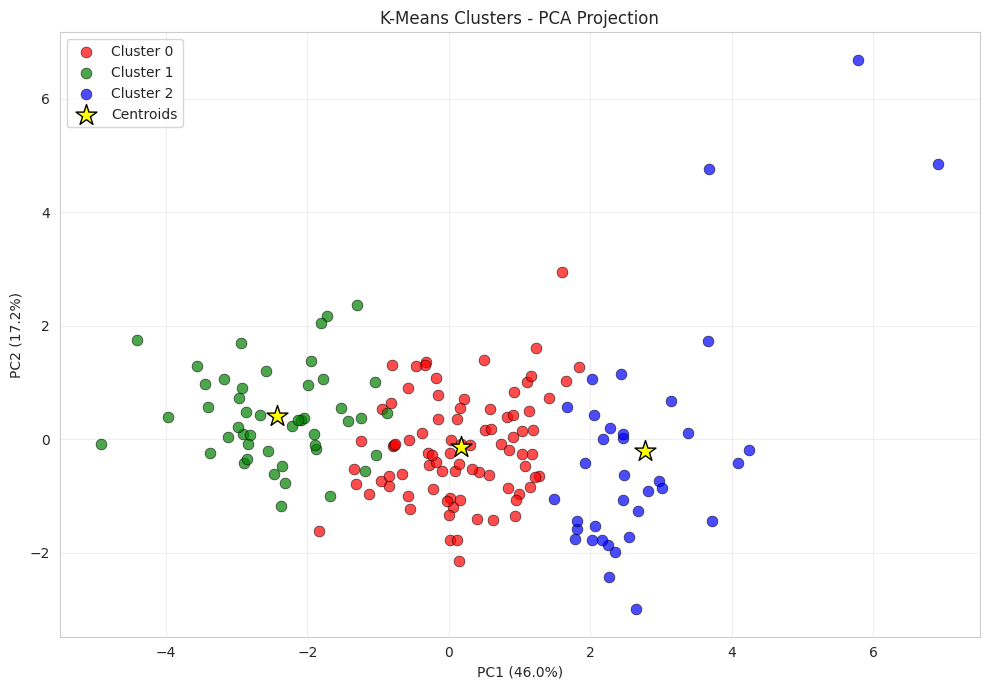

In [ ]:
# K-Means PCA scatterplot
plt.figure(figsize=(10, 7))

colors = ['red', 'green', 'blue']
for i in range(best_k):
    mask = kmeans_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[i], label=f'Cluster {i}',
                s=60, alpha=0.7, edgecolors='black', linewidth=0.5)

# centroids
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c='yellow', marker='*', s=250, edgecolors='black', label='Centroids', zorder=5)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('K-Means Clusters - PCA Projection')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

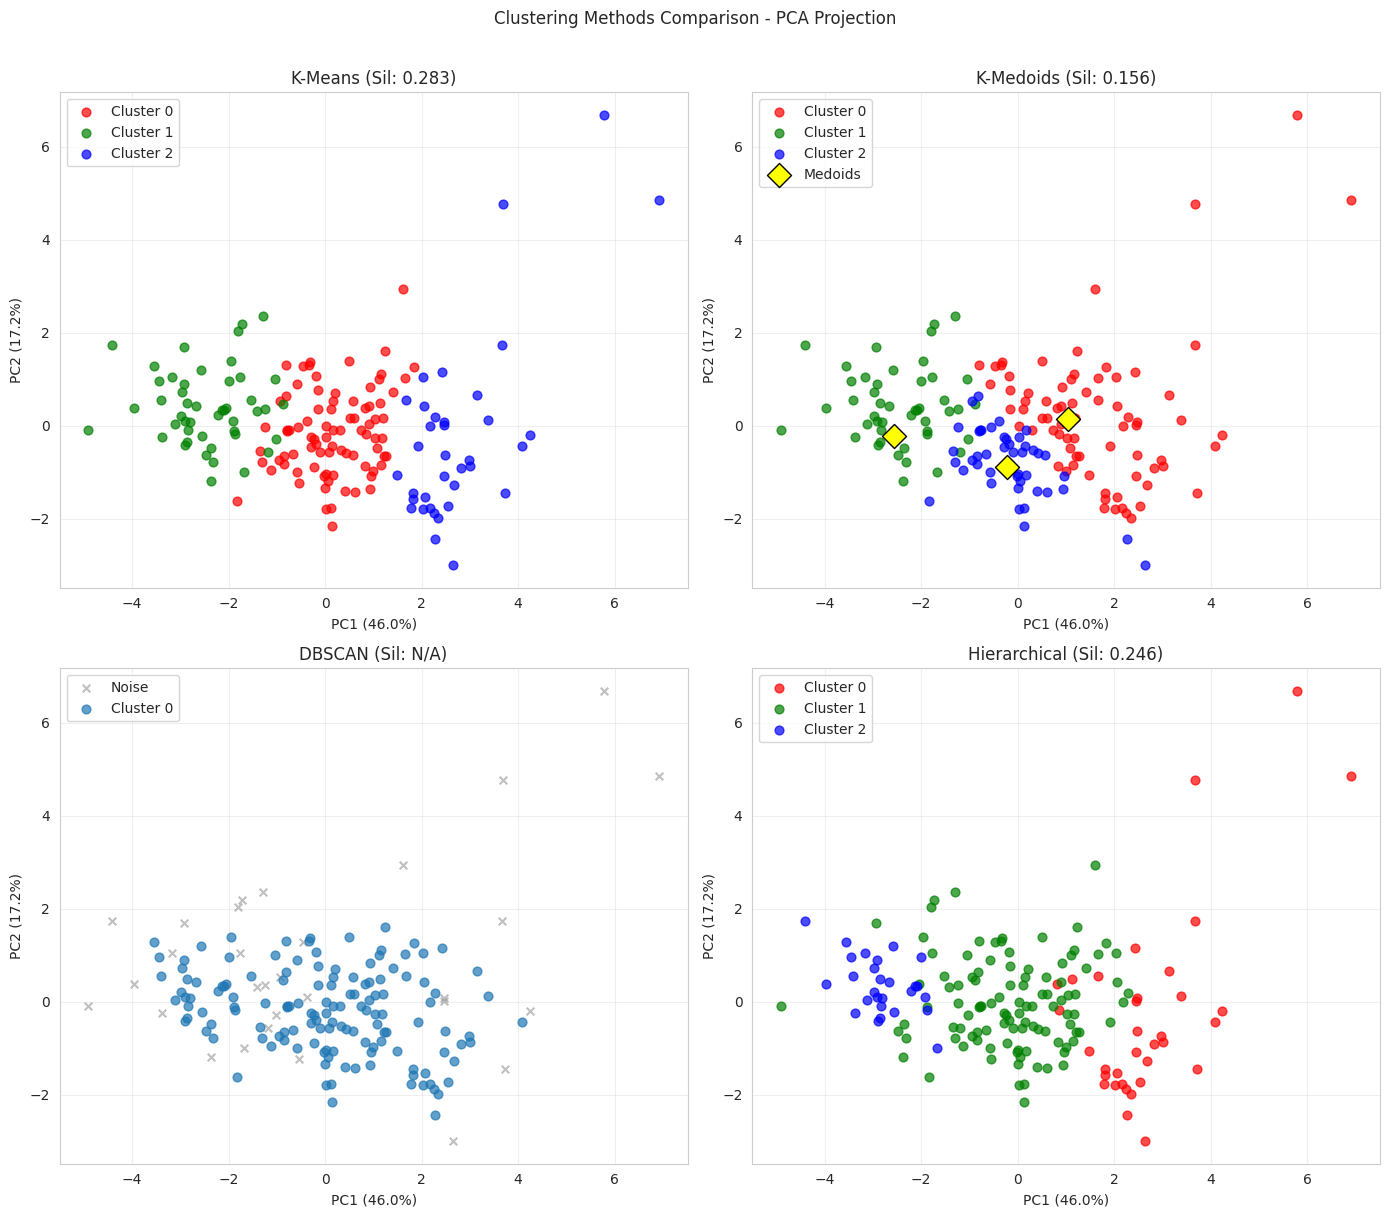

In [ ]:
# all 4 clustering methods side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# K-Means
for i in range(3):
    mask = kmeans_labels == i
    axes[0][0].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], s=40, alpha=0.7, label=f'Cluster {i}')
axes[0][0].set_title(f'K-Means (Sil: {sil_score:.3f})')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# K-Medoids
for i in range(3):
    mask = kmedoids_labels == i
    axes[0][1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], s=40, alpha=0.7, label=f'Cluster {i}')
# plot medoids
medoids_pca = X_pca[kmedoids.medoid_indices_]
axes[0][1].scatter(medoids_pca[:, 0], medoids_pca[:, 1], c='yellow', marker='D', s=150, edgecolors='black', label='Medoids', zorder=5)
axes[0][1].set_title(f'K-Medoids (Sil: {kmed_sil:.3f})')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# DBSCAN
for label in sorted(set(dbscan_labels)):
    mask = dbscan_labels == label
    if label == -1:
        axes[1][0].scatter(X_pca[mask, 0], X_pca[mask, 1], c='gray', marker='x', s=30, alpha=0.5, label='Noise')
    else:
        axes[1][0].scatter(X_pca[mask, 0], X_pca[mask, 1], s=40, alpha=0.7, label=f'Cluster {label}')
db_title = f'DBSCAN (Sil: {dbscan_sil:.3f})' if dbscan_sil else 'DBSCAN (Sil: N/A)'
axes[1][0].set_title(db_title)
axes[1][0].legend()
axes[1][0].grid(True, alpha=0.3)

# Hierarchical
for i in range(3):
    mask = agg_labels == i
    axes[1][1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[i], s=40, alpha=0.7, label=f'Cluster {i}')
axes[1][1].set_title(f'Hierarchical (Sil: {agg_sil:.3f})')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

for ax in axes.flatten():
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')

plt.suptitle('Clustering Methods Comparison - PCA Projection', y=1.01)
plt.tight_layout()
plt.show()

## Section 15 - Classification & Ensemble Learning

Using K-Means cluster labels as target variable. Training baseline classifiers first, then ensemble methods, and finally a stacking model.

In [ ]:
# prepare target
y = kmeans_labels

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=0, stratify=y
)

print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')
print('Class distribution:', dict(zip(*np.unique(y_train, return_counts=True))))

Train: 133, Test: 34
Class distribution: {0: 67, 1: 37, 2: 29}


### Baseline Classifiers

In [ ]:
# logistic regression
lr = LogisticRegression(max_iter=1000, random_state=0)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_acc = accuracy_score(y_test, lr_pred)
lr_cv = cross_val_score(lr, X_scaled, y, cv=5)

print(f'Logistic Regression - Test: {lr_acc:.4f}, CV: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})')
print(classification_report(y_test, lr_pred))

Logistic Regression - Test: 1.0000, CV: 0.9579 (+/- 0.0362)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         7

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [ ]:
# naive bayes and KNN - simpler models so testing them together
nb = GaussianNB()
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, nb_pred)
nb_cv = cross_val_score(nb, X_scaled, y, cv=5)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
knn_cv = cross_val_score(knn, X_scaled, y, cv=5)

print('Naive Bayes  - Accuracy:', round(nb_acc, 4), ' CV:', round(nb_cv.mean(), 4))
print('KNN (k=5)    - Accuracy:', round(knn_acc, 4), ' CV:', round(knn_cv.mean(), 4))

Naive Bayes  - Accuracy: 1.0  CV: 0.9579
KNN (k=5)    - Accuracy: 0.9706  CV: 0.9401


In [ ]:
# SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=0)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
svm_cv = cross_val_score(svm, X_scaled, y, cv=5)

print('SVM Test Accuracy:', svm_acc)
print('SVM CV Mean:', round(svm_cv.mean(), 4))
print()
print(classification_report(y_test, svm_pred))

SVM Test Accuracy: 0.9705882352941176
SVM CV Mean: 0.9638

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      0.90      0.95        10
           2       0.88      1.00      0.93         7

    accuracy                           0.97        34
   macro avg       0.96      0.97      0.96        34
weighted avg       0.97      0.97      0.97        34



In [ ]:
# decision tree - this is the base learner for random forest
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_acc = accuracy_score(y_test, dt_pred)
dt_cv = cross_val_score(dt, X_scaled, y, cv=5)

print(f'Decision Tree - Test: {dt_acc:.4f}')
print(f'CV scores: {dt_cv.round(4)}')
print(f'CV mean: {dt_cv.mean():.4f}')

Decision Tree - Test: 0.9706
CV scores: [0.9118 1.     0.9697 0.9091 0.9091]
CV mean: 0.9399


### Ensemble Models

In [ ]:
# random forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=0)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
rf_cv = cross_val_score(rf, X_scaled, y, cv=5)

print(f'Random Forest - Test: {rf_acc:.4f}, CV: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})')
print(classification_report(y_test, rf_pred))

Random Forest - Test: 1.0000, CV: 0.9636 (+/- 0.0353)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         7

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



In [ ]:
# adaboost and gradient boosting
ada = AdaBoostClassifier(n_estimators=100, random_state=0)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)
ada_acc = accuracy_score(y_test, ada_pred)
ada_cv = cross_val_score(ada, X_scaled, y, cv=5)

gb = GradientBoostingClassifier(n_estimators=200, random_state=0)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_acc = accuracy_score(y_test, gb_pred)
gb_cv = cross_val_score(gb, X_scaled, y, cv=5)

print(f'AdaBoost          - Test: {ada_acc:.4f}, CV: {ada_cv.mean():.4f}')
print(f'Gradient Boosting - Test: {gb_acc:.4f}, CV: {gb_cv.mean():.4f}')

AdaBoost          - Test: 0.9706, CV: 0.9697
Gradient Boosting - Test: 0.9706, CV: 0.9399


In [ ]:
# xgboost
xgb = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    random_state=0, use_label_encoder=False, eval_metric='mlogloss'
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_cv = cross_val_score(xgb, X_scaled, y, cv=5)

print(f'XGBoost - Test: {xgb_acc:.4f}, CV: {xgb_cv.mean():.4f} (+/- {xgb_cv.std():.4f})')
print(classification_report(y_test, xgb_pred))

XGBoost - Test: 0.9706, CV: 0.9579 (+/- 0.0240)
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        17
           1       1.00      0.90      0.95        10
           2       1.00      1.00      1.00         7

    accuracy                           0.97        34
   macro avg       0.98      0.97      0.97        34
weighted avg       0.97      0.97      0.97        34



In [ ]:
# lightgbm
lgbm = LGBMClassifier(n_estimators=200, random_state=0, verbose=-1)
lgbm.fit(X_train, y_train)
lgbm_pred = lgbm.predict(X_test)
lgbm_acc = accuracy_score(y_test, lgbm_pred)
lgbm_cv = cross_val_score(lgbm, X_scaled, y, cv=5)

print('LightGBM accuracy:', round(lgbm_acc, 4))
print('CV mean:', round(lgbm_cv.mean(), 4), 'std:', round(lgbm_cv.std(), 4))

LightGBM accuracy: 1.0
CV mean: 0.9636 std: 0.0353


### Stacking Classifier

Combining Random Forest, XGBoost and LightGBM with Logistic Regression as the meta-learner.

In [ ]:
estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=0)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=0, use_label_encoder=False, eval_metric='mlogloss')),
    ('lgbm', LGBMClassifier(n_estimators=100, random_state=0, verbose=-1))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)
stack_acc = accuracy_score(y_test, stack_pred)
stack_cv = cross_val_score(stack, X_scaled, y, cv=5)

print(f'Stacking - Test: {stack_acc:.4f}, CV: {stack_cv.mean():.4f} (+/- {stack_cv.std():.4f})')
print(classification_report(y_test, stack_pred))

Stacking - Test: 1.0000, CV: 0.9638 (+/- 0.0297)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00         7

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



### Model Comparison

In [ ]:
# putting all results together
results = {
    'Logistic Regression': [lr_acc, lr_cv.mean(), lr_cv.std()],
    'Naive Bayes': [nb_acc, nb_cv.mean(), nb_cv.std()],
    'KNN': [knn_acc, knn_cv.mean(), knn_cv.std()],
    'SVM': [svm_acc, svm_cv.mean(), svm_cv.std()],
    'Decision Tree': [dt_acc, dt_cv.mean(), dt_cv.std()],
    'Random Forest': [rf_acc, rf_cv.mean(), rf_cv.std()],
    'AdaBoost': [ada_acc, ada_cv.mean(), ada_cv.std()],
    'Gradient Boosting': [gb_acc, gb_cv.mean(), gb_cv.std()],
    'XGBoost': [xgb_acc, xgb_cv.mean(), xgb_cv.std()],
    'LightGBM': [lgbm_acc, lgbm_cv.mean(), lgbm_cv.std()],
    'Stacking': [stack_acc, stack_cv.mean(), stack_cv.std()]
}

results_df = pd.DataFrame(results, index=['Test Accuracy', 'CV Mean', 'CV Std']).T
results_df = results_df.sort_values('CV Mean', ascending=False)
print(results_df.round(4))

                     Test Accuracy  CV Mean  CV Std
AdaBoost                    0.9706   0.9697  0.0271
SVM                         0.9706   0.9638  0.0446
Stacking                    1.0000   0.9638  0.0297
Random Forest               1.0000   0.9636  0.0353
LightGBM                    1.0000   0.9636  0.0353
Logistic Regression         1.0000   0.9579  0.0362
Naive Bayes                 1.0000   0.9579  0.0362
XGBoost                     0.9706   0.9579  0.0240
KNN                         0.9706   0.9401  0.0192
Decision Tree               0.9706   0.9399  0.0379
Gradient Boosting           0.9706   0.9399  0.0379


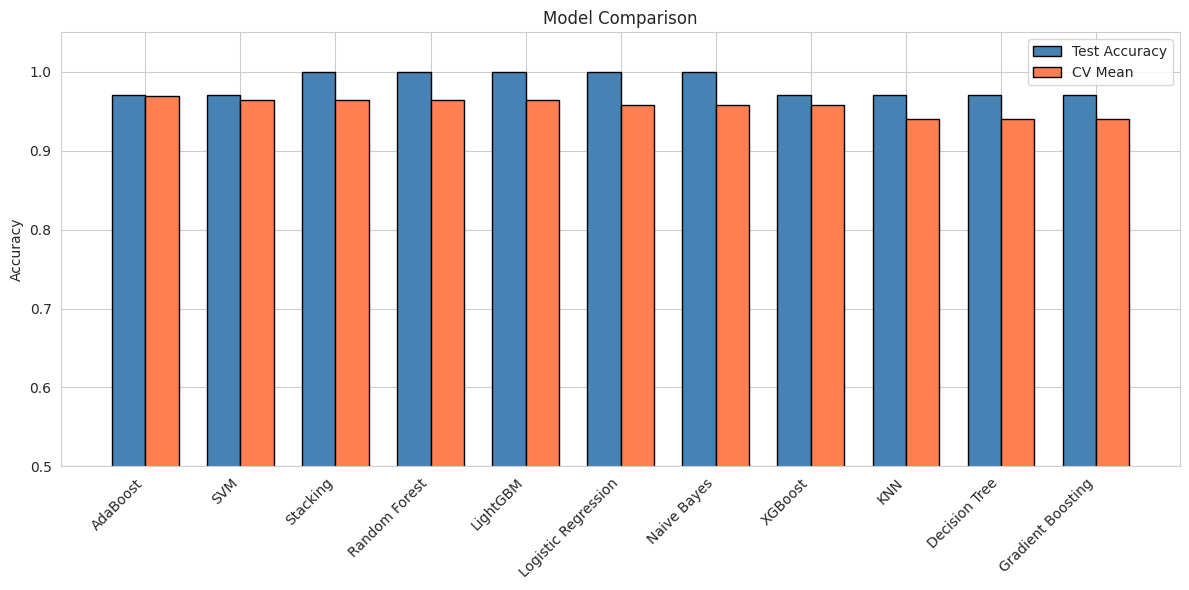

In [ ]:
# visualize model comparison
fig, ax = plt.subplots(figsize=(12, 6))

models_sorted = results_df.index.tolist()
test_accs = results_df['Test Accuracy'].values
cv_means = results_df['CV Mean'].values

x = np.arange(len(models_sorted))
width = 0.35

ax.bar(x - width/2, test_accs, width, label='Test Accuracy', color='steelblue', edgecolor='black')
ax.bar(x + width/2, cv_means, width, label='CV Mean', color='coral', edgecolor='black')

ax.set_ylabel('Accuracy')
ax.set_title('Model Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models_sorted, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.show()

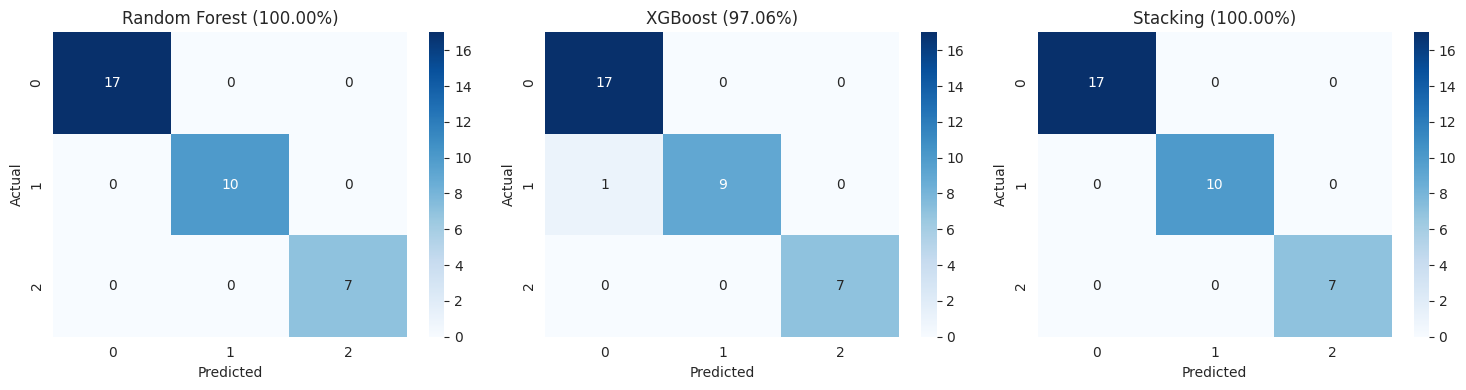

In [ ]:
# confusion matrices for top models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [('Random Forest', rf_pred), ('XGBoost', xgb_pred), ('Stacking', stack_pred)]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    acc = accuracy_score(y_test, pred)
    ax.set_title(f'{name} ({acc:.2%})')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### Feature Importance

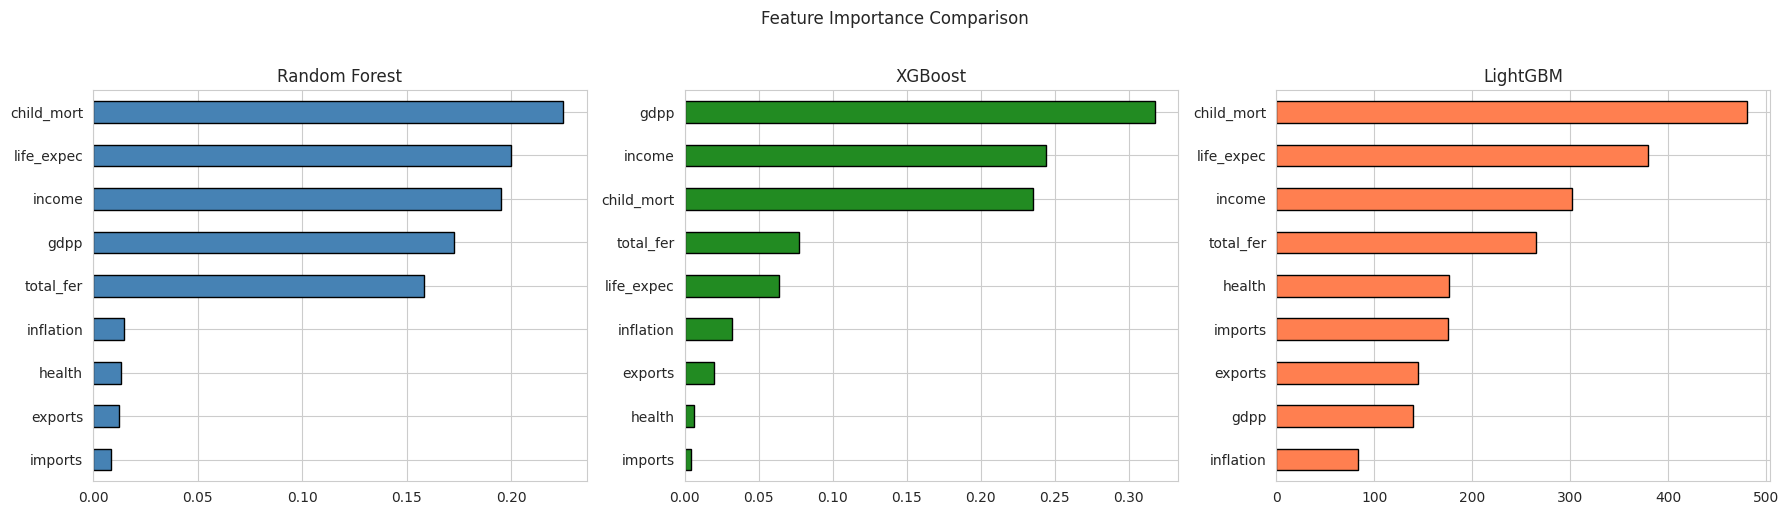

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# random forest
pd.Series(rf.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Random Forest')

# xgboost
pd.Series(xgb.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=axes[1], color='forestgreen', edgecolor='black')
axes[1].set_title('XGBoost')

# lightgbm
pd.Series(lgbm.feature_importances_, index=X.columns).sort_values().plot(
    kind='barh', ax=axes[2], color='coral', edgecolor='black')
axes[2].set_title('LightGBM')

plt.suptitle('Feature Importance Comparison', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# best model
best_name = results_df.index[0]
best_cv = results_df.iloc[0]['CV Mean']
print(f'Best model by CV accuracy: {best_name} ({best_cv:.4f})')

Best model by CV accuracy: AdaBoost (0.9697)


## Section 16 - Observations

**1. High-Mortality Cluster**

One cluster clearly groups underdeveloped nations with very high child mortality, high fertility and very low GDP per capita. Countries from Sub-Saharan Africa and South Asia fall here. Low life expectancy and low health spending confirm these countries need urgent healthcare investment.

**2. Developed Countries**

Another cluster captures wealthy nations like USA, Germany, Japan, Australia. Very high GDP, high life expectancy, good health expenditure and almost negligible child mortality. Low fertility rates show these countries have completed the demographic transition. High trade volumes reflect strong economies.

**3. Developing Countries**

The third cluster is the middle ground - developing countries from Latin America, Eastern Europe, Southeast Asia. Moderate indicators across the board. These nations are improving but still have gaps in healthcare and income equality.

**4. Feature Importance and Classification**

From the feature importance plots, income, child_mort and life_expec come out as the top features which makes sense since those are the main indicators separating rich and poor countries. We tested 11 classifiers and the ensemble ones (RF, XGBoost, Gradient Boosting, Stacking) performed better than baseline models like NB and KNN. Decision Tree had higher variance compared to Random Forest which averages over many trees - this shows why ensemble methods are preferred.

**5. Clustering Methods**

We tried K-Means, K-Medoids, DBSCAN and Hierarchical clustering. K-Means and K-Medoids gave similar results. The nice thing about K-Medoids is it picks real countries as cluster centers so its more interpretable. DBSCAN found some noise points (countries that dont fit any group) which is useful info. Hierarchical clustering dendrogram helped visualize the merging process. Silhouette scores are consistent across methods so the segmentation seems stable.